# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import utils
from models.gaussian_naive_bayes import GaussianNaiveBayes
import matplotlib.pyplot as plt

# Data Preprocessing

In [2]:
columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
           'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv('../data/abalone/abalone.data', header=None, names=columns)
df = df.drop(columns=['Sex'])

# Convert rings to age classes
conditions = [
    df['Rings'] <= 8,
    df['Rings'].between(9, 11),
    df['Rings'] >= 12
]
age_classes = ['Young', 'Adult', 'Old']
df['Age_class'] = np.select(conditions, age_classes, default='Unknown')

# Model Training

In [3]:
X = df.drop(columns=['Age_class', 'Rings'])
y = df['Age_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

gaussian_naive_bayes = GaussianNaiveBayes()
gaussian_naive_bayes.fit(X_train, y_train)

# Evaluation

In [4]:
y_pred_log = gaussian_naive_bayes.predict(X_test)
y_pred = gaussian_naive_bayes.predict(X_test, use_log=False)

results = pd.DataFrame({
    'Method': ['With Log Probabilities', 'Without Log Probabilities'],
    'Accuracy': [
        utils.compute_accuracy(y_test, y_pred_log),
        utils.compute_accuracy(y_test, y_pred)
    ]
})
print(results)

                      Method  Accuracy
0     With Log Probabilities  0.550239
1  Without Log Probabilities  0.550239


# Visualization

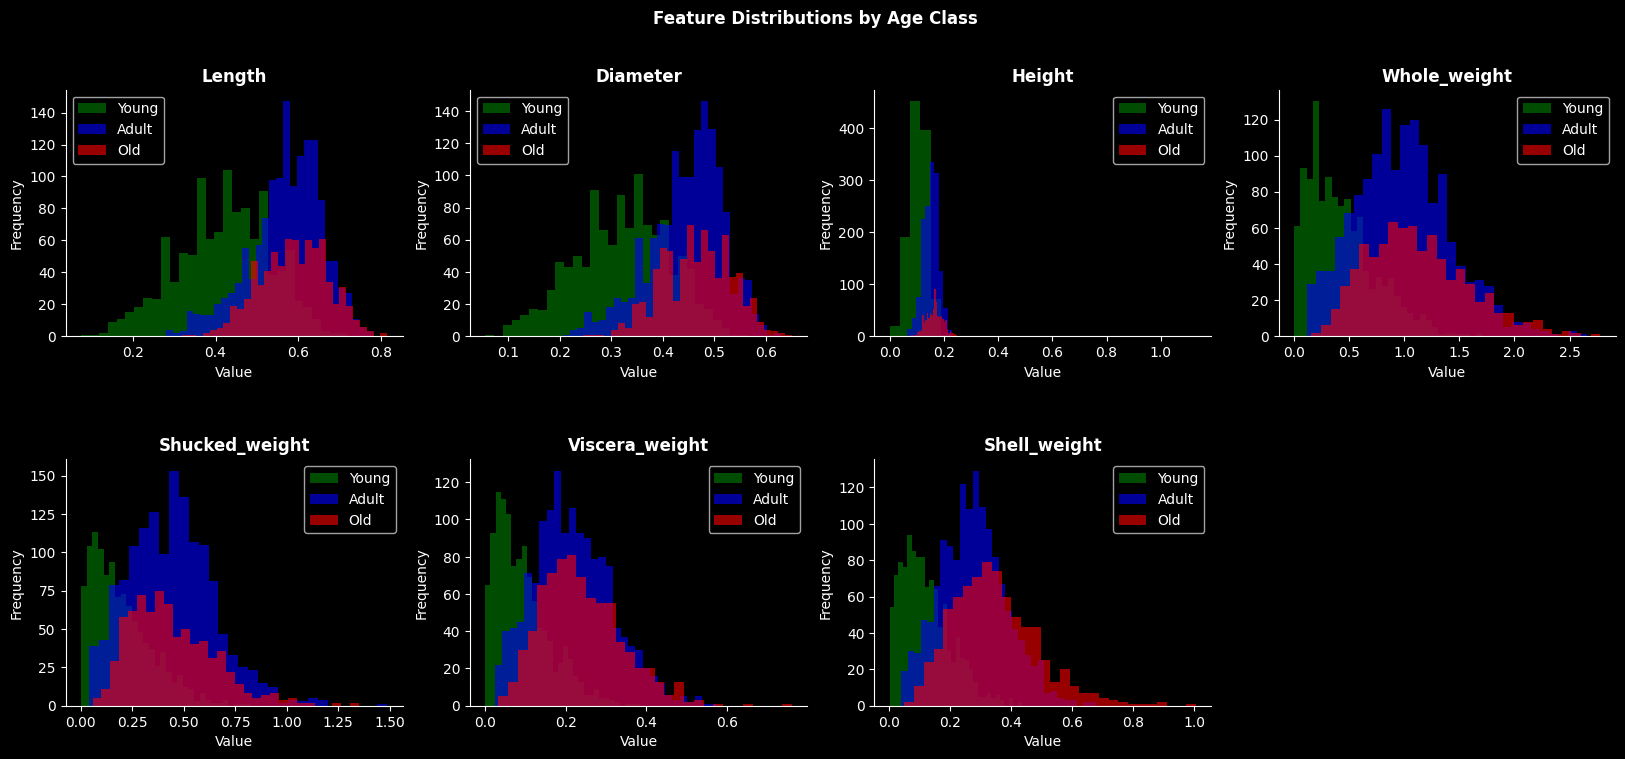

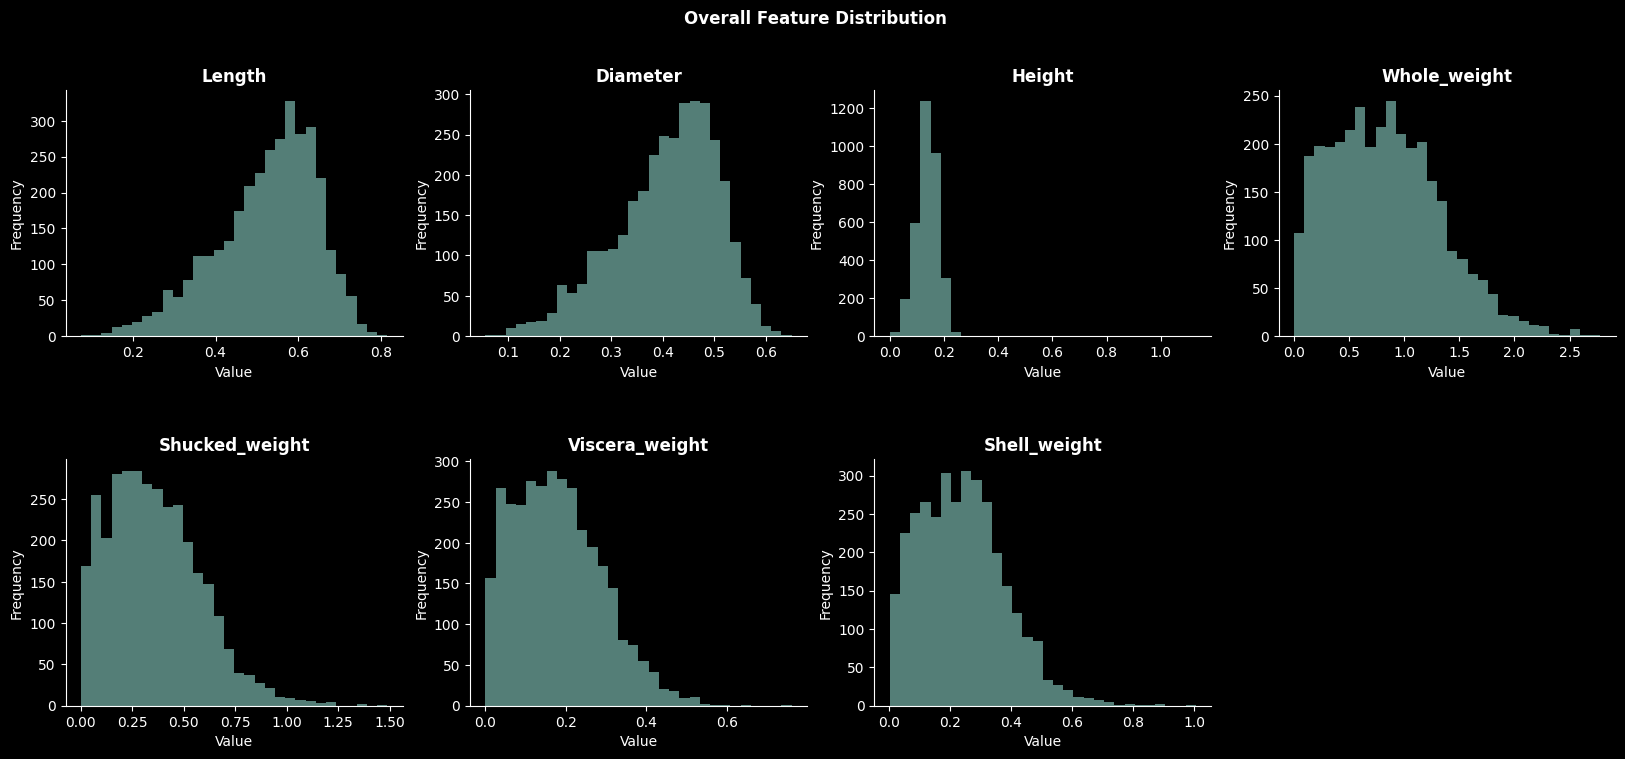

In [5]:
import math

features = X.columns
n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

# Plot feature distribution separated by age class
fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes1 = axes1.flatten()
colors = {'Young': 'Green', 'Adult': 'Blue', 'Old': 'Red'}

for i, feature in enumerate(features):
    for age_class, color in colors.items():
        subset = X_train[y_train == age_class][feature]
        axes1[i].hist(subset, bins=30, label=age_class, color=color, alpha=0.6)

    axes1[i].set_title(feature, fontweight='bold')
    axes1[i].set_xlabel('Value')
    axes1[i].set_ylabel('Frequency')
    axes1[i].legend()
    axes1[i].spines[['top', 'right']].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axes1)):
    axes1[j].set_visible(False)

fig1.suptitle('Feature Distributions by Age Class', fontweight='bold')
fig1.subplots_adjust(hspace=0.5)

# Plot overall feature distribution with no class separation
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes2 = axes2.flatten()

for i, feature in enumerate(features):
    axes2[i].hist(X_train[feature], bins=30, alpha=0.6)
    axes2[i].set_title(feature, fontweight='bold')
    axes2[i].set_xlabel('Value')
    axes2[i].set_ylabel('Frequency')
    axes2[i].spines[['top', 'right']].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

fig2.suptitle('Overall Feature Distribution', fontweight='bold')
fig2.subplots_adjust(hspace=0.5)
plt.show()